# Preprocessing for the 5 time-series datasets

In [1]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

## Shared preprocessing and investigation functions

In [2]:
def save_windows(filename, window_sizes):
    os.makedirs("window-sizes", exist_ok=True)
    path = os.path.join("window-sizes", filename)
    with open(path, "w") as f:
        json.dump({"window_sizes": window_sizes}, f, indent=4)

def save_processed(df, filename):
    os.makedirs("processed-data", exist_ok=True)
    df.to_csv(os.path.join("processed-data", filename), index=True)

def inspect_series(df, column):
    x = df[column]
    print("Shape:", df.shape)
    print("Start:", df.index.min())
    print("End:", df.index.max())
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate timestamps:", df.index.duplicated().sum())
    print("\nSummary:")
    print(x.describe())
    print("\nMost common timestamp differences:")
    print(df.index.to_series().diff().value_counts().head())

def plot_series(series, title, ylabel):
    plt.figure(figsize=(14, 4))
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def stationarity_tests(series):
    x = series.dropna().astype(float)
    adf = adfuller(x)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(x, regression="c", nlags="auto")
    result = {
        "ADF statistic": adf[0],
        "ADF p-value": adf[1],
        "KPSS statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1],
    }
    for key, value in result.items():
        print(f"{key}: {value}")
    return result

def plot_rolling_stats(series, window, title):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    plt.figure(figsize=(14, 4))
    plt.plot(rolling_mean.index, rolling_mean.values)
    plt.title(f"{title} rolling mean, window={window}")
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(14, 4))
    plt.plot(rolling_std.index, rolling_std.values)
    plt.title(f"{title} rolling standard deviation, window={window}")
    plt.tight_layout()
    plt.show()

def block_statistics(series, n_blocks=10):
    blocks = np.array_split(series.dropna().to_numpy(), n_blocks)
    return pd.DataFrame({
        "block": range(n_blocks),
        "mean": [b.mean() for b in blocks],
        "std": [b.std() for b in blocks],
        "min": [b.min() for b in blocks],
        "max": [b.max() for b in blocks],
    }).set_index("block")

def plot_dependence(series, acf_lags=200, pacf_lags=100):
    x = series.dropna()
    acf_lags = min(acf_lags, len(x) - 1)
    pacf_lags = min(pacf_lags, max(1, len(x) // 2 - 1))
    plot_acf(x, lags=acf_lags)
    plt.title("ACF")
    plt.tight_layout()
    plt.show()
    plot_pacf(x, lags=pacf_lags, method="ywm")
    plt.title("PACF")
    plt.tight_layout()
    plt.show()

def inspect_outliers(series, xlabel):
    x = series.dropna()
    z_scores = np.abs((x - x.mean()) / x.std())
    print("Number of |z| > 3 values:", int((z_scores > 3).sum()))
    plt.figure(figsize=(8, 4))
    plt.boxplot(x, vert=False)
    plt.xlabel(xlabel)
    plt.title("Boxplot")
    plt.tight_layout()
    plt.show()

def run_diagnostics(df, column, title, ylabel, rolling_window, acf_lags=200, pacf_lags=100):
    inspect_series(df, column)
    plot_series(df[column], title, ylabel)
    tests = stationarity_tests(df[column])
    plot_rolling_stats(df[column], rolling_window, title)
    display(block_statistics(df[column]))
    plot_dependence(df[column], acf_lags, pacf_lags)
    inspect_outliers(df[column], ylabel)
    return tests

def parse_univariate_tsf(path):
    metadata = {}
    data_lines = []
    in_data = False
    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue
            if line.lower() == "@data":
                in_data = True
                continue
            if not in_data:
                if line.startswith("@"):
                    parts = line[1:].split(maxsplit=1)
                    metadata[parts[0].lower()] = parts[1] if len(parts) > 1 else ""
                continue
            data_lines.append(line)
    if len(data_lines) != 1:
        raise ValueError(f"Expected one univariate series in TSF file, found {len(data_lines)}")
    parts = data_lines[0].split(":")
    values = pd.to_numeric(pd.Series(parts[-1].split(",")), errors="coerce").to_numpy()
    start_text = parts[-2]
    start = pd.to_datetime(start_text, format="%Y-%m-%d %H-%M-%S", errors="coerce")
    if pd.isna(start):
        start = pd.to_datetime(start_text)
    return values, start, metadata

## Dataset 1: Stationary baseline: Atmospheric pressure

**Small explanation of the dataset:** Atmospheric pressure (`Press_mm_hg`) is taken from the UCI Appliances Energy Prediction dataset. The original data were recorded every 10 minutes over approximately 4.5 months, with the weather measurements originating from the nearby Chievres Airport weather station.

**Why it was chosen:** It provides a real-world, strongly autocorrelated series that is approximately stationary, making it useful as the stationary baseline against which the recurrent architectures can be compared.

**Number of observations:** 19,735 observations at 10-minute intervals. The full series is retained without temporal aggregation so that the processed dataset also contains 19,735 observations.

**Source:** https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

In [3]:
ds1 = pd.read_csv("raw-data/ds1.csv")
ds1["date"] = pd.to_datetime(ds1["date"])
ds1 = ds1.sort_values("date").set_index("date")[["Press_mm_hg"]]
ds1.head()

,Press_mm_hg
date,
2016-01-11 17:00:00,733.5
2016-01-11 17:10:00,733.6
2016-01-11 17:20:00,733.7
2016-01-11 17:30:00,733.8
2016-01-11 17:40:00,733.9


Shape: (19735, 1)
Start: 2016-01-11 17:00:00
End: 2016-05-27 18:00:00

Missing values:
Press_mm_hg    0
dtype: int64

Duplicate timestamps: 0

Summary:
count    19735.000000
mean       755.522602
std          7.399441
min        729.300000
25%        750.933333
50%        756.100000
75%        760.933333
max        772.300000
Name: Press_mm_hg, dtype: float64

Most common timestamp differences:
date
0 days 00:10:00    19734
Name: count, dtype: int64


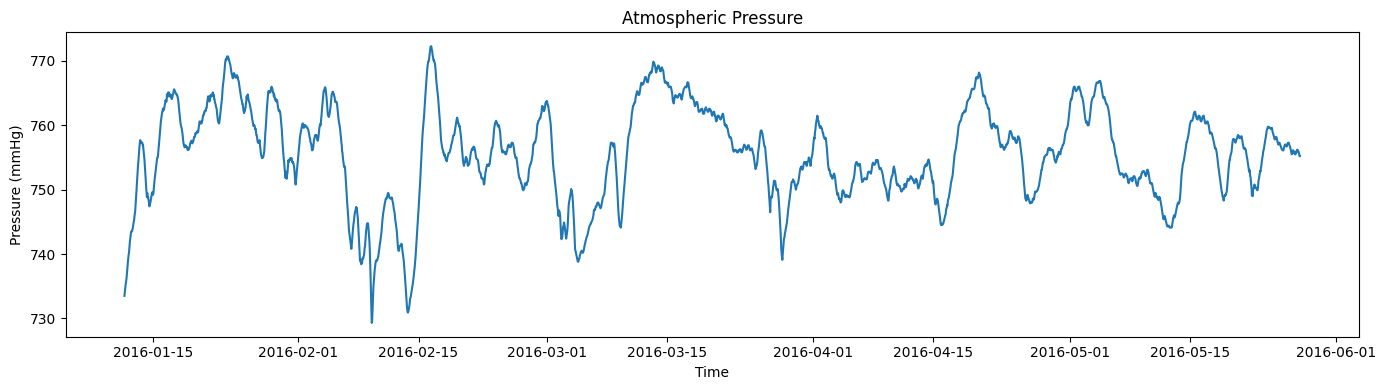

ADF statistic: -5.717285627128709
ADF p-value: 7.072888713778745e-07
KPSS statistic: 0.24467971273746408
KPSS p-value: 0.1


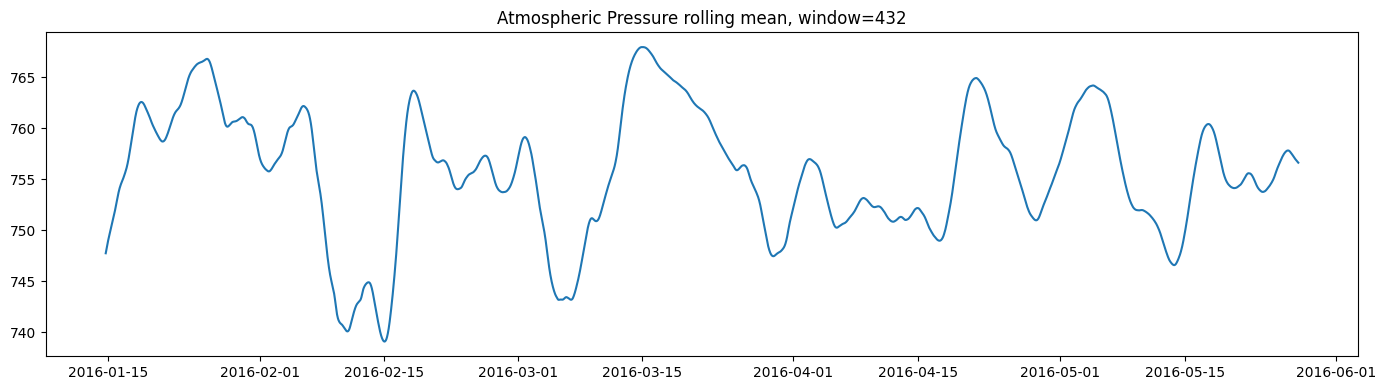

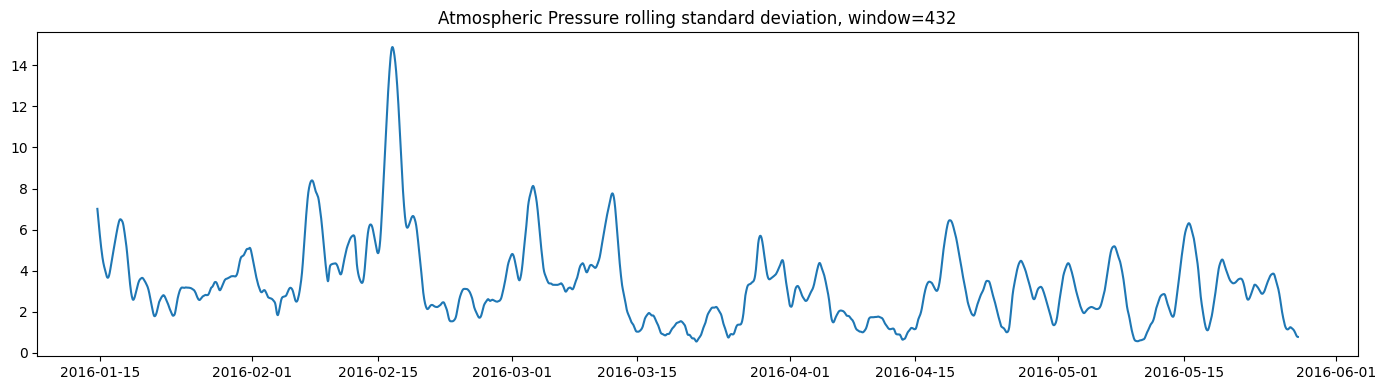

,mean,std,min,max
block,,,,
0,758.805750,8.026244,733.500000,770.7
1,757.923506,6.078942,740.566667,766.0
2,750.128445,10.816020,729.300000,772.3
3,752.114564,6.745229,738.800000,763.8
4,761.055142,7.068920,744.100000,769.9
5,754.764420,4.968058,739.100000,762.1
6,751.035302,2.295790,744.500000,754.7
7,757.388165,5.309901,747.500000,768.2
8,755.576322,7.135787,744.100000,766.9


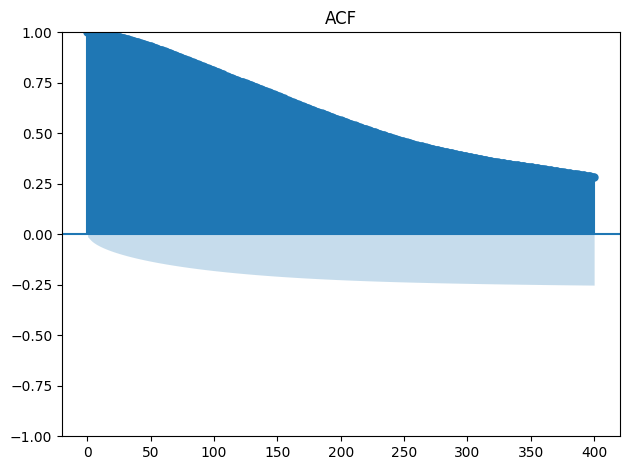

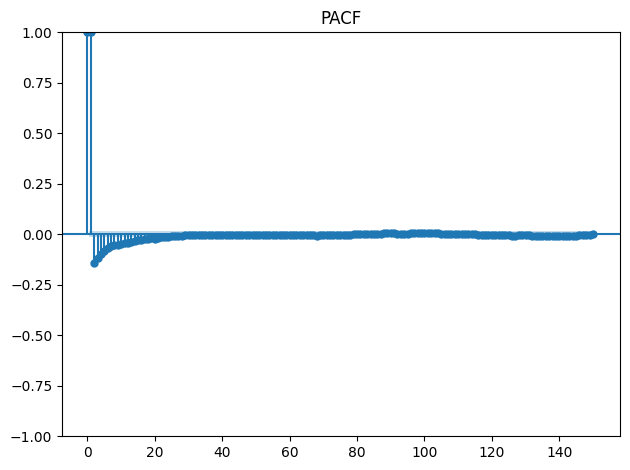

Number of |z| > 3 values: 107


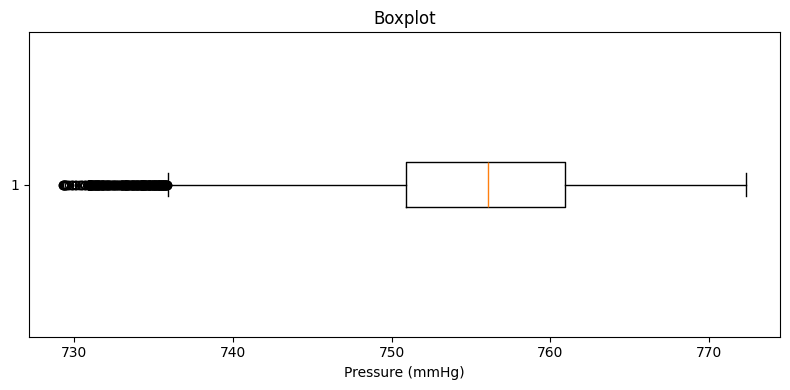

In [4]:
ds1_tests = run_diagnostics(
    ds1,
    "Press_mm_hg",
    "Atmospheric Pressure",
    "Pressure (mmHg)",
    rolling_window=432,
    acf_lags=400,
    pacf_lags=150,
)

### Preprocessing decision

The full 10-minute pressure series is retained in level form. No temporal aggregation, differencing, detrending, smoothing, or automatic outlier removal is applied. Keeping the original sampling interval gives approximately 20,000 observations while preserving the pressure dynamics. Scaling will be performed later inside each training fold only.

In [5]:
# 10-minute data:
# 12 = 2 hours, 48 = 8 hours,
# 144 = 1 day, 288 = 2 days
ds1_windows = [12, 48, 144, 288]
save_processed(ds1, "ds1.csv")
save_windows("ds1-windows.json", ds1_windows)

## Dataset 2: Non-stationary non-seasonal: Bitcoin BTC/USD

**Small explanation of the dataset:** This dataset contains hourly Bitcoin BTC/USD market data. Only the hourly closing price is used so that the forecasting task remains univariate.

**Why it was chosen:** Bitcoin price levels are strongly non-stationary and exhibit substantial temporal dependence and regime changes, while lacking the clean repeating annual or daily seasonal pattern seen in the explicitly seasonal datasets. This makes it a useful contrast to the approximately stationary pressure series and the strongly seasonal temperature series.

**Number of observations:** The source file contains hourly BTC/USD data over many years. A contiguous subset of approximately 20,000 hourly observations is selected for the experiment.

**Source:** https://github.com/Julian-Andres-Thomas/BTC-USD

In [6]:
ds2base = pd.read_csv("raw-data/ds2.csv")

timestamp_candidates = [c for c in ds2base.columns if c.lower() in {"timestamp", "datetime", "date", "time"}]
if not timestamp_candidates:
    raise ValueError(f"No timestamp column found. Columns: {list(ds2base.columns)}")

close_candidates = [c for c in ds2base.columns if c.lower() == "close"]
if not close_candidates:
    raise ValueError(f"No Close column found. Columns: {list(ds2base.columns)}")

time_col = timestamp_candidates[0]
close_col = close_candidates[0]

ds2base[time_col] = pd.to_datetime(ds2base[time_col], utc=True, errors="coerce")
ds2base = ds2base.dropna(subset=[time_col]).sort_values(time_col)

ds2 = (
    ds2base[[time_col, close_col]]
    .rename(columns={time_col: "date", close_col: "bitcoin_close"})
    .set_index("date")
)

ds2.head()

,bitcoin_close
date,
2015-01-01 00:00:00+00:00,316.23
2015-01-01 01:00:00+00:00,317.53
2015-01-01 02:00:00+00:00,318.99
2015-01-01 03:00:00+00:00,318.88
2015-01-01 04:00:00+00:00,321.00


In [7]:
print("Full hourly rows:", len(ds2))
print("Missing values:", ds2["bitcoin_close"].isna().sum())
print("Duplicate timestamps:", ds2.index.duplicated().sum())
print("Most common timestamp differences:")
print(ds2.index.to_series().diff().value_counts().head())

Full hourly rows: 93822
Missing values: 0
Duplicate timestamps: 0
Most common timestamp differences:
date
0 days 01:00:00    93820
0 days 19:00:00        1
Name: count, dtype: int64


### Select a contiguous approximately 20,000-observation interval

A contiguous block is used rather than randomly sampling timestamps so that the temporal structure is preserved. The most recent 20,000 hourly observations are selected here. This corresponds to a little over two years of hourly data.

In [8]:
# Select a contiguous recent section and regularize it to exact hourly spacing.
# The source contains a small gap in the most recent 20,000 rows, so we first
# take a slightly larger section, reindex hourly, interpolate only the small
# internal gaps, and then keep the final 20,000 hourly observations.

ds2 = ds2.tail(20250).copy()

full_hourly_index = pd.date_range(
    ds2.index.min(),
    ds2.index.max(),
    freq="h"
)

ds2 = ds2.reindex(full_hourly_index)
ds2.index.name = "date"

print("Missing Bitcoin values before interpolation:", ds2["bitcoin_close"].isna().sum())

ds2["bitcoin_close"] = ds2["bitcoin_close"].interpolate(
    method="time",
    limit_area="inside"
)

ds2 = ds2.dropna().tail(20000).copy()

print("Selected rows:", len(ds2))
print("Start:", ds2.index.min())
print("End:", ds2.index.max())
print("Remaining missing values:", ds2["bitcoin_close"].isna().sum())
print("Irregular timestamp gaps:",
      (ds2.index.to_series().diff().dropna() != pd.Timedelta("1h")).sum())

ds2.head()

Missing Bitcoin values before interpolation: 18
Selected rows: 20000
Start: 2023-06-04 16:00:00+00:00
End: 2025-09-14 23:00:00+00:00
Remaining missing values: 0
Irregular timestamp gaps: 0


,bitcoin_close
date,
2023-06-04 16:00:00+00:00,27218.0
2023-06-04 17:00:00+00:00,27259.0
2023-06-04 18:00:00+00:00,27242.0
2023-06-04 19:00:00+00:00,27190.0
2023-06-04 20:00:00+00:00,27181.0


Shape: (20000, 1)
Start: 2023-06-04 16:00:00+00:00
End: 2025-09-14 23:00:00+00:00

Missing values:
bitcoin_close    0
dtype: int64

Duplicate timestamps: 0

Summary:
count     20000.00000
mean      68208.38810
std       28746.92546
min       24858.00000
25%       42582.75000
50%       65753.00000
75%       95700.75000
max      123898.00000
Name: bitcoin_close, dtype: float64

Most common timestamp differences:
date
0 days 01:00:00    19999
Name: count, dtype: int64


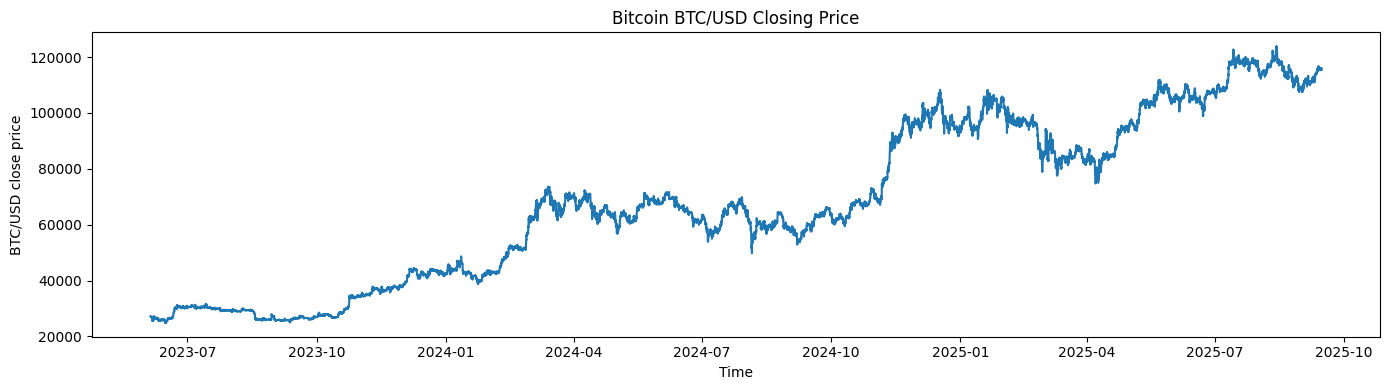

ADF statistic: -0.5675614371865003
ADF p-value: 0.8781446525423238
KPSS statistic: 20.896717396153907
KPSS p-value: 0.01


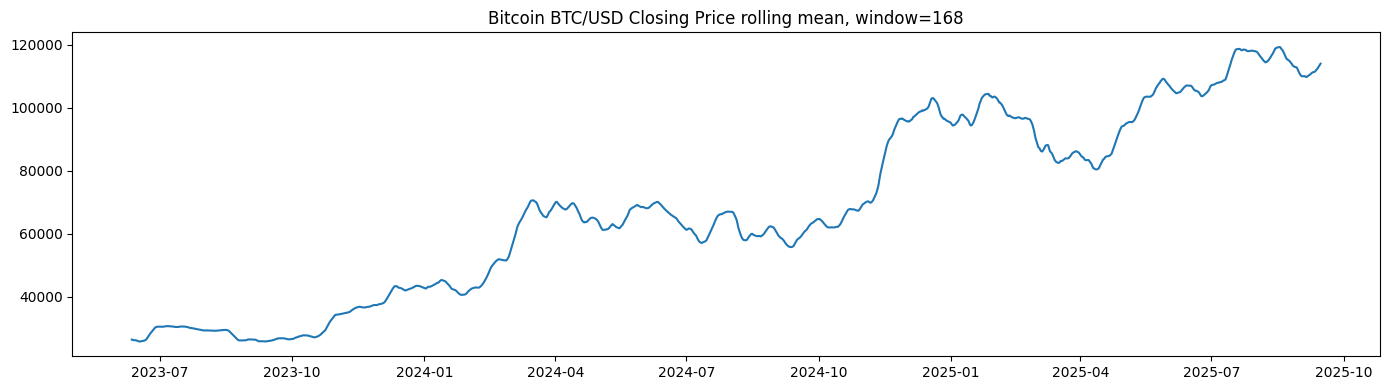

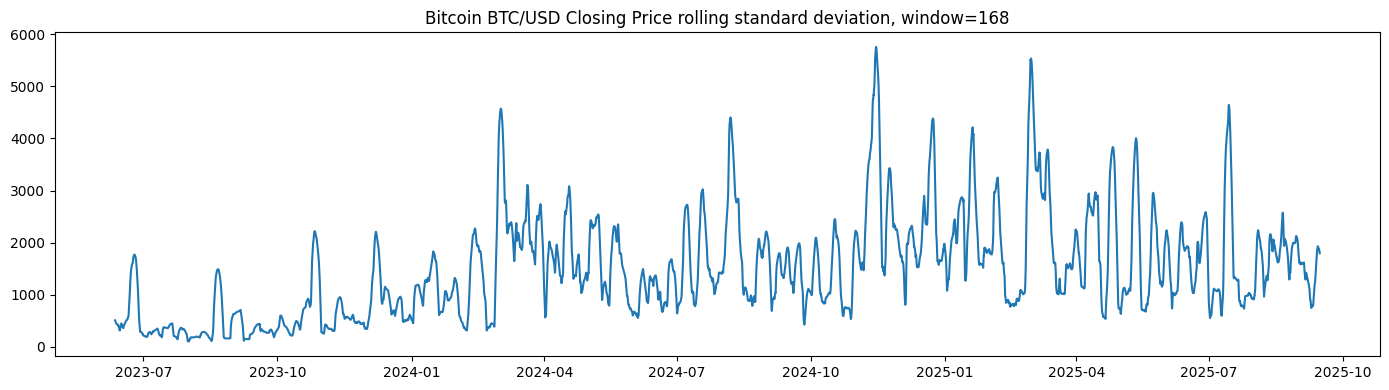

,mean,std,min,max
block,,,,
0,28750.9010,1802.151594,24858.0,31637.0
1,29531.1560,4007.267581,25005.0,37884.0
2,41913.8435,2485.347095,35758.0,48664.0
3,62952.2570,7097.201789,46917.0,73608.0
4,64536.8065,3962.487023,53921.0,71645.0
5,61176.2040,3413.628885,49814.0,69805.0
6,88445.6460,12787.677792,65634.0,108276.0
7,93037.9265,7639.003101,77600.0,108176.0
8,97853.3775,9674.204519,74724.0,111763.0


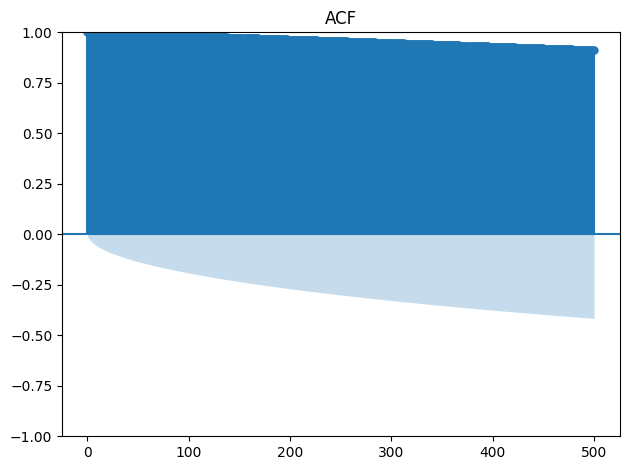

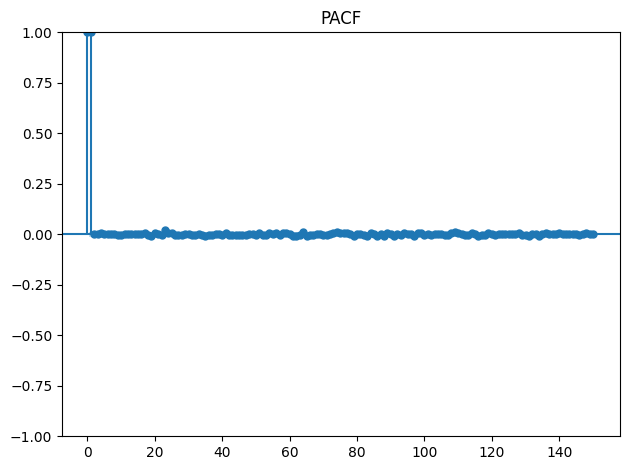

Number of |z| > 3 values: 0


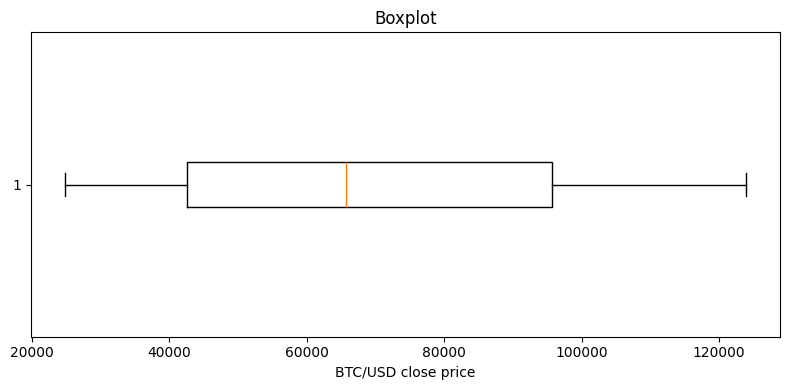

In [9]:
ds2_tests = run_diagnostics(
    ds2,
    "bitcoin_close",
    "Bitcoin BTC/USD Closing Price",
    "BTC/USD close price",
    rolling_window=168,
    acf_lags=500,
    pacf_lags=150,
)

### Stationarity transformation check

First differencing is examined only as a diagnostic. The main forecasting series remains the raw BTC/USD closing-price level so that the non-stationarity of Dataset 2 is preserved as part of the experimental design.

In [10]:
ds2_diff = ds2.diff().dropna()
ds2_diff_tests = stationarity_tests(ds2_diff["bitcoin_close"])

ADF statistic: -32.10343295250341
ADF p-value: 0.0
KPSS statistic: 0.033194967921842344
KPSS p-value: 0.1


### Preprocessing decision

The raw Bitcoin closing-price level is retained. The selected interval is reindexed to exact hourly spacing and the small internal source gap is filled using time interpolation before the final 20,000 contiguous hourly observations are selected. No differencing, detrending, smoothing, log transformation, or automatic outlier removal is applied. Scaling will be performed later inside each training fold only.

In [11]:
# Hourly data:
# 12 = 12 hours, 24 = 1 day,
# 168 = 1 week, 336 = 2 weeks
ds2_windows = [12, 24, 168, 336]
save_processed(ds2, "ds2.csv")
save_windows("ds2-windows.json", ds2_windows)

## Dataset 3: Strongly seasonal: Beijing temperature

**Small explanation of the dataset:** The Beijing PM2.5 dataset contains hourly meteorological and air-quality measurements recorded in Beijing from 2010 to 2014. Only the temperature variable (`TEMP`) is used so that the forecasting task remains univariate. The hourly observations are aggregated into 2-hour mean temperatures.

**Why it was chosen:** The temperature series contains a very clear repeating annual cycle across five complete years. This makes it a clean example of strong seasonality with several repeated seasonal cycles and enough observations for recurrent-neural-network training.

**Number of observations:** The original dataset contains 43,824 hourly rows. Aggregating the temperature observations to 2-hour means produces approximately 21,912 observations across 2010-2014.

**Source:** https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

Chen, S. (2015). Beijing PM2.5 [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JS49.

In [12]:
ds3base = pd.read_csv("raw-data/ds3.csv")

ds3base["date"] = pd.to_datetime(
    dict(
        year=ds3base["year"],
        month=ds3base["month"],
        day=ds3base["day"],
        hour=ds3base["hour"],
    )
)

ds3base = ds3base.sort_values("date")

ds3 = (
    ds3base[["date", "TEMP"]]
    .rename(columns={"TEMP": "temperature"})
    .set_index("date")
)

ds3.head()

,temperature
date,
2010-01-01 00:00:00,-11.0
2010-01-01 01:00:00,-12.0
2010-01-01 02:00:00,-11.0
2010-01-01 03:00:00,-14.0
2010-01-01 04:00:00,-12.0


In [13]:
print("Original rows:", len(ds3))
print("Missing temperature values:", ds3["temperature"].isna().sum())
print("Duplicate timestamps:", ds3.index.duplicated().sum())
print("Most common timestamp differences:")
print(ds3.index.to_series().diff().value_counts().head())

Original rows: 43824
Missing temperature values: 0
Duplicate timestamps: 0
Most common timestamp differences:
date
0 days 01:00:00    43823
Name: count, dtype: int64


In [14]:
ds3 = ds3.resample("2h").mean()

print("2-hour rows:", len(ds3))
print("Missing values after resampling:", ds3["temperature"].isna().sum())

ds3.head()

2-hour rows: 21912
Missing values after resampling: 0


,temperature
date,
2010-01-01 00:00:00,-11.5
2010-01-01 02:00:00,-12.5
2010-01-01 04:00:00,-11.0
2010-01-01 06:00:00,-9.0
2010-01-01 08:00:00,-8.5


Shape: (21912, 1)
Start: 2010-01-01 00:00:00
End: 2014-12-31 22:00:00

Missing values:
temperature    0
dtype: int64

Duplicate timestamps: 0

Summary:
count    21912.000000
mean        12.448521
std         12.175835
min        -18.500000
25%          1.500000
50%         13.500000
75%         23.000000
max         41.500000
Name: temperature, dtype: float64

Most common timestamp differences:
date
0 days 02:00:00    21911
Name: count, dtype: int64


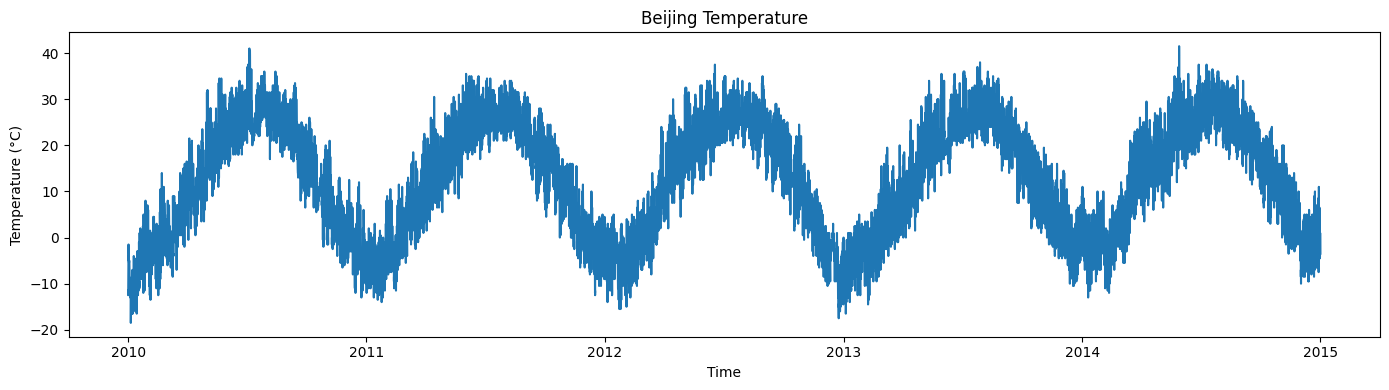

ADF statistic: -2.7024608870801634
ADF p-value: 0.07361339533272349
KPSS statistic: 0.39727148862342443
KPSS p-value: 0.07833125490369637


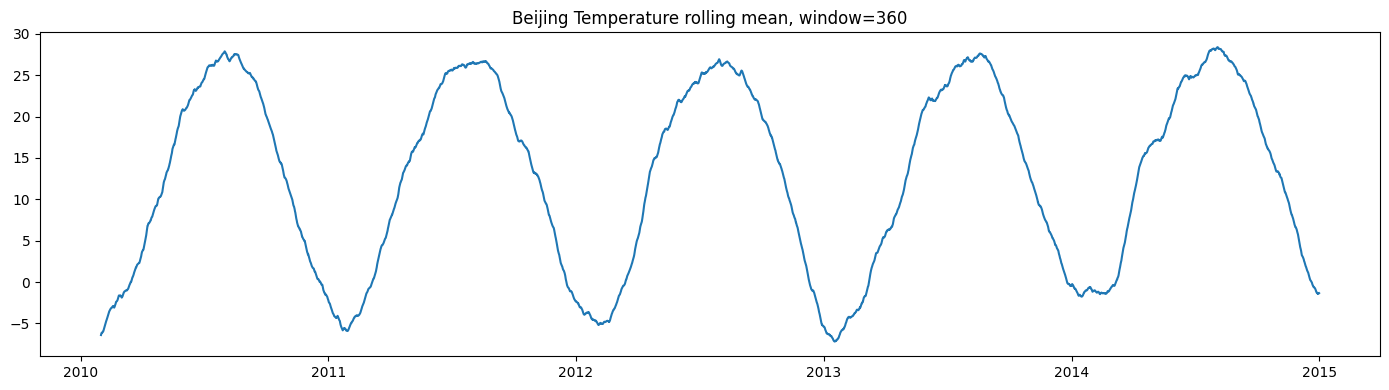

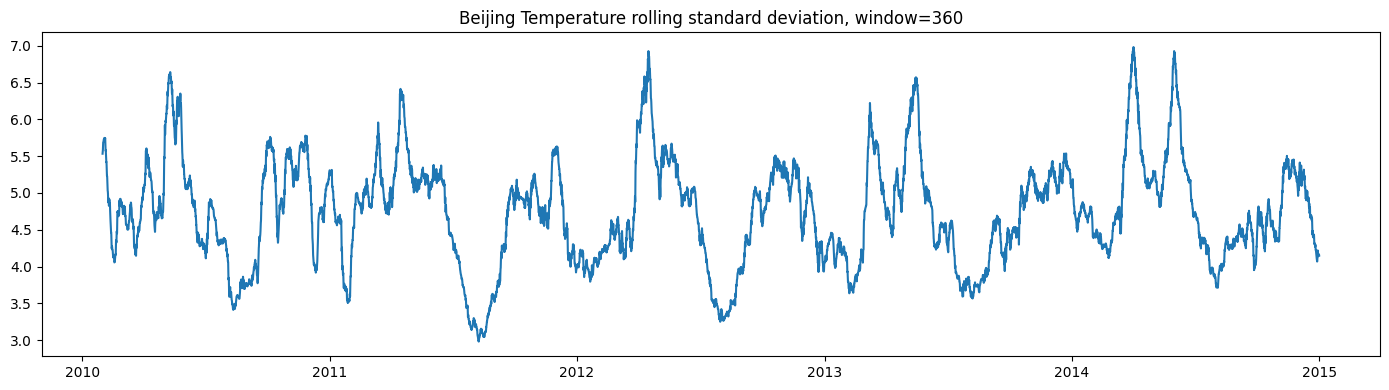

,mean,std,min,max
block,,,,
0,8.770073,12.404436,-18.5,36.5
1,14.453695,12.166426,-13.0,41.0
2,10.543359,12.163065,-14.0,35.5
3,14.581470,11.371054,-12.5,34.5
4,10.097216,12.425089,-15.5,37.5
5,13.914651,12.400375,-17.5,35.0
6,9.428343,11.994489,-16.5,35.5
7,15.344363,11.280265,-10.5,38.0
8,12.085577,11.538966,-13.0,41.5


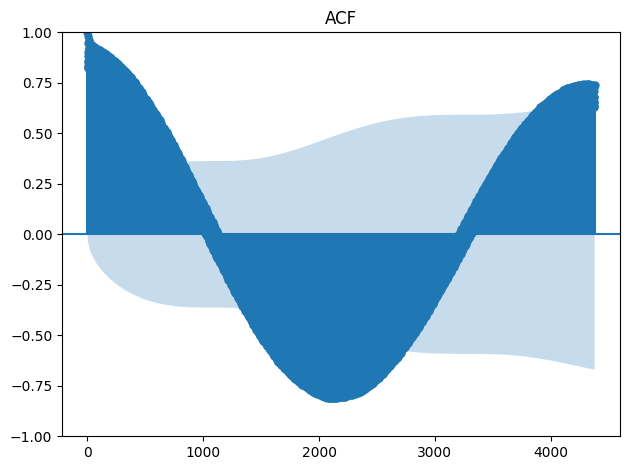

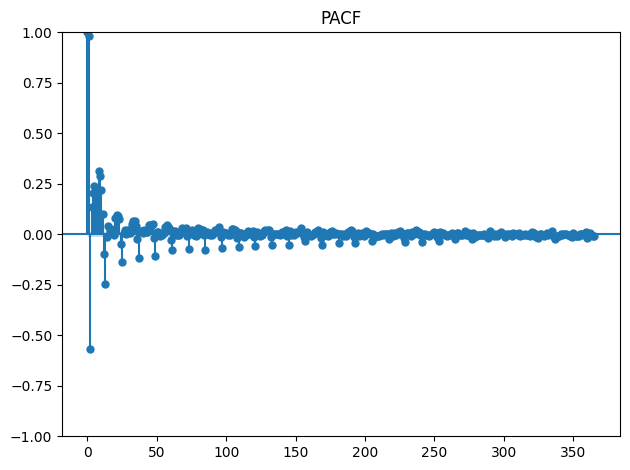

Number of |z| > 3 values: 0


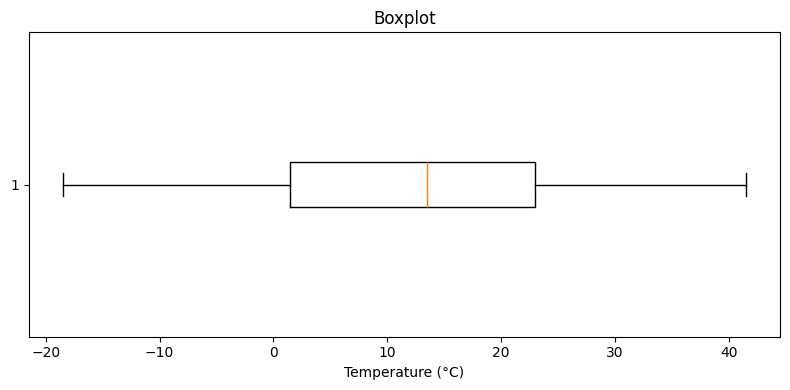

In [15]:
ds3_tests = run_diagnostics(
    ds3,
    "temperature",
    "Beijing Temperature",
    "Temperature (°C)",
    rolling_window=360,
    acf_lags=4380,
    pacf_lags=365,
)

### Preprocessing decision

The hourly temperature series is aggregated to 2-hour means. This keeps the processed dataset close to 20,000 observations while preserving the full five-year record and the strong annual seasonal structure. The temperature series is kept in level form: no differencing, detrending, deseasonalization, smoothing, or automatic outlier removal is applied. Scaling will be performed later inside each training fold only.

In [16]:
# 2-hour data:
# 12 = 1 day, 84 = 1 week,
# 360 = 1 month, 1095 ≈ 3 months
ds3_windows = [12, 84, 360, 1095]

save_processed(ds3, "ds3.csv")
save_windows("ds3-windows.json", ds3_windows)

## Dataset 4: Trend and seasonal: Mauna Loa atmospheric CO₂

**Small explanation of the dataset:** This dataset contains daily mean atmospheric carbon-dioxide concentrations measured at the Mauna Loa Observatory in Hawaii by NOAA's Global Monitoring Laboratory. The series contains a strong long-term increase in atmospheric CO₂ together with a clear repeating annual seasonal cycle.

**Why it was chosen:** It provides a much cleaner trend-plus-seasonality forecasting problem than the previously investigated electricity-demand datasets. The upward long-term trend and annual oscillation are both visible directly in the raw series, making the temporal structure easy to justify and distinct from Dataset 3, which is dominated by seasonality without a comparable long-term trend.

**Number of observations:** NOAA's daily record begins in 1974. The notebook uses daily observations through the end of 2021 to avoid the extended Mauna Loa observational interruption beginning in late 2022. This gives roughly 17,000 daily time steps before any missing-day handling.

**Source:** https://gml.noaa.gov/ccgg/trends/data.html

**Direct daily CSV:** https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_daily_mlo.csv

In [17]:
ds4_path = "raw-data/ds4.csv"

ds4base = pd.read_csv(
    ds4_path,
    comment="#",
    header=None,
    names=["year", "month", "day", "decimal_date", "co2"]
)

ds4base["date"] = pd.to_datetime(
    dict(
        year=ds4base["year"],
        month=ds4base["month"],
        day=ds4base["day"],
    )
)

ds4base = ds4base.sort_values("date")

ds4 = (
    ds4base[["date", "co2"]]
    .set_index("date")
    .loc[:"2021-12-31"]
    .copy()
)

ds4.head()

,co2
date,
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
1974-05-22,333.21
1974-05-23,333.05


In [18]:
print("Observed rows:", len(ds4))
print("Start:", ds4.index.min())
print("End:", ds4.index.max())
print("Missing CO2 values:", ds4["co2"].isna().sum())
print("Duplicate timestamps:", ds4.index.duplicated().sum())
print("Most common timestamp differences:")
print(ds4.index.to_series().diff().value_counts().head(10))

Observed rows: 14607
Start: 1974-05-19 00:00:00
End: 2021-12-31 00:00:00
Missing CO2 values: 0
Duplicate timestamps: 0
Most common timestamp differences:
date
1 days     12875
2 days      1189
3 days       327
4 days       125
5 days        46
6 days        18
7 days         8
8 days         4
9 days         3
11 days        3
Name: count, dtype: int64


### Daily timestamp quality check

The NOAA file contains measured daily means rather than an artificially complete calendar. Missing calendar days are therefore identified explicitly before modelling. Because atmospheric CO₂ changes smoothly at daily resolution, short internal gaps can be interpolated after the size and distribution of the gaps have been inspected.

In [19]:
if ds4.index.duplicated().any():
    ds4 = ds4.groupby(level=0).mean()

full_daily_index = pd.date_range(
    ds4.index.min(),
    ds4.index.max(),
    freq="D"
)

missing_days = full_daily_index.difference(ds4.index)

print("Observed daily rows after duplicate consolidation:", len(ds4))
print("Missing calendar days:", len(missing_days))
print("First missing dates:")
print(missing_days[:30])

Observed daily rows after duplicate consolidation: 14607
Missing calendar days: 2787
First missing dates:
DatetimeIndex(['1974-05-24', '1974-05-25', '1974-06-01', '1974-06-02',
               '1974-06-03', '1974-06-26', '1974-06-29', '1974-07-01',
               '1974-07-07', '1974-07-14', '1974-07-17', '1974-07-28',
               '1974-07-29', '1974-07-30', '1974-08-05', '1974-08-07',
               '1974-08-14', '1974-08-16', '1974-08-22', '1974-09-02',
               '1974-09-04', '1974-09-08', '1974-09-12', '1974-09-13',
               '1974-09-16', '1974-09-22', '1974-09-26', '1974-10-02',
               '1974-10-04', '1974-10-09'],
              dtype='datetime64[us]', freq=None)


In [20]:
missing_mask = ~full_daily_index.isin(ds4.index)

gap_lengths = []
current_gap = 0

for missing in missing_mask:
    if missing:
        current_gap += 1
    elif current_gap:
        gap_lengths.append(current_gap)
        current_gap = 0

if current_gap:
    gap_lengths.append(current_gap)

print("Number of missing-day gaps:", len(gap_lengths))
print("Largest missing-day gap:", max(gap_lengths) if gap_lengths else 0)
print("Median missing-day gap:", np.median(gap_lengths) if gap_lengths else 0)

Number of missing-day gaps: 1731
Largest missing-day gap: 36
Median missing-day gap: 1.0


### Regularize the daily series

The series is reindexed to a complete daily calendar and internal missing days are filled using time interpolation. The interpolation is applied only after inspecting the gap lengths above. This preserves equal time steps for recurrent input windows while retaining the long-term trend and annual seasonal cycle.

In [21]:
ds4 = ds4.reindex(full_daily_index)
ds4.index.name = "date"

ds4["co2"] = ds4["co2"].interpolate(
    method="time",
    limit_area="inside"
)

print("Daily observations after regularization:", len(ds4))
print("Remaining missing values:", ds4["co2"].isna().sum())

ds4.head()

Daily observations after regularization: 17394
Remaining missing values: 0


,co2
date,
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
1974-05-22,333.21
1974-05-23,333.05


Shape: (17394, 1)
Start: 1974-05-19 00:00:00
End: 2021-12-31 00:00:00

Missing values:
co2    0
dtype: int64

Duplicate timestamps: 0

Summary:
count    17394.000000
mean       368.715243
std         25.050369
min        326.060000
25%        347.397214
50%        365.680000
75%        389.057500
max        421.320000
Name: co2, dtype: float64

Most common timestamp differences:
date
1 days    17393
Name: count, dtype: int64


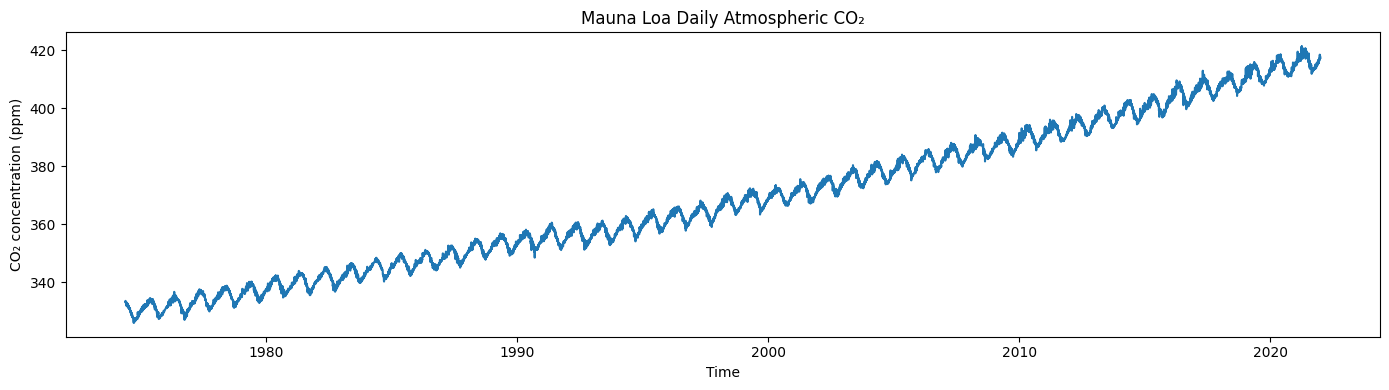

ADF statistic: -0.9553649002139926
ADF p-value: 0.7691940103844165
KPSS statistic: 21.986932521322743
KPSS p-value: 0.01


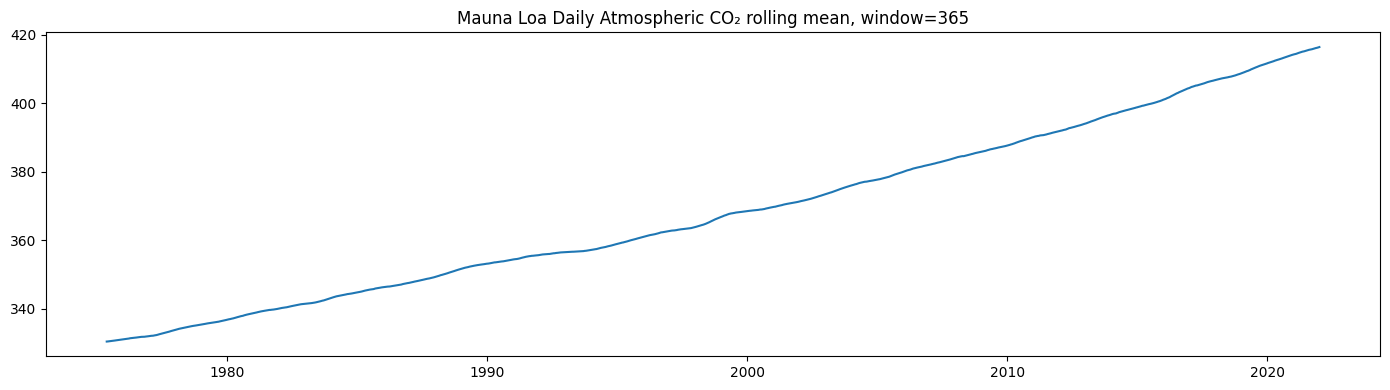

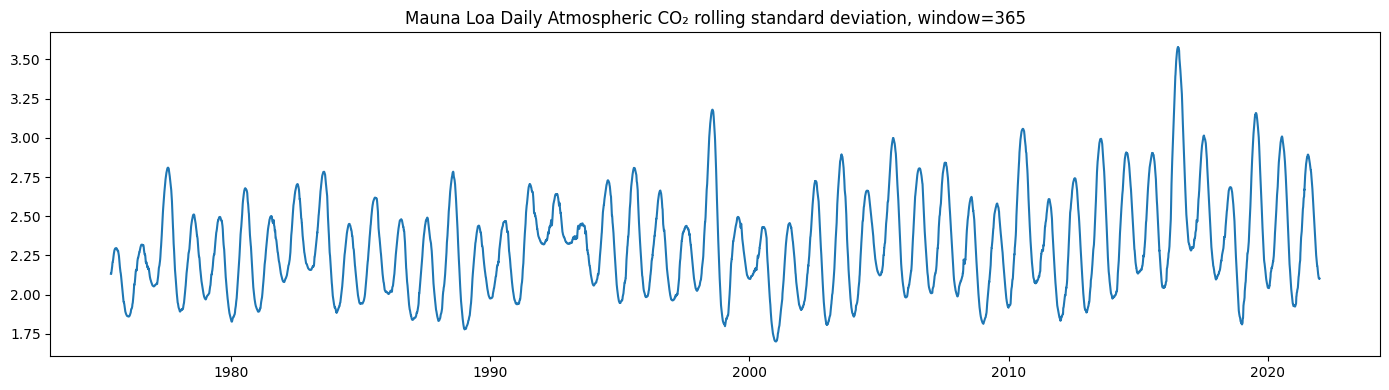

,mean,std,min,max
block,,,,
0,332.737578,2.813725,326.06,338.87
1,340.118086,2.922178,333.01,346.59
2,347.704790,3.109589,340.29,355.07
3,354.964474,2.887501,347.86,361.26
4,361.152300,3.284781,352.82,368.71
5,370.094491,2.863642,363.21,376.75
6,379.750285,3.569845,372.40,388.05
7,389.125610,3.766733,379.84,397.97
8,399.783071,4.312351,390.37,410.14


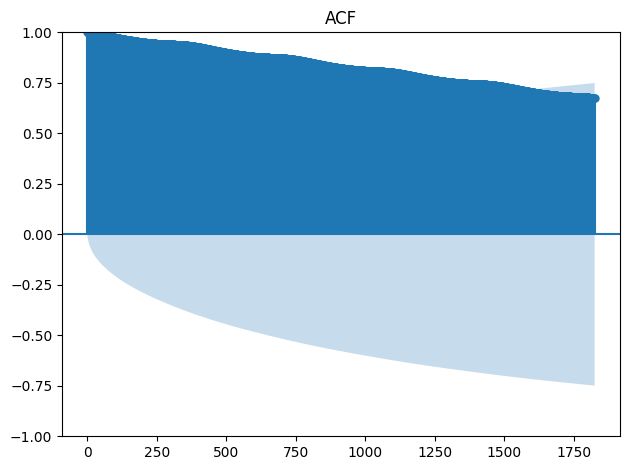

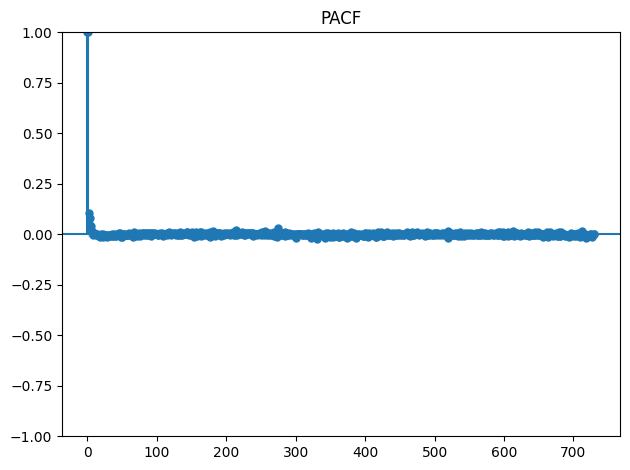

Number of |z| > 3 values: 0


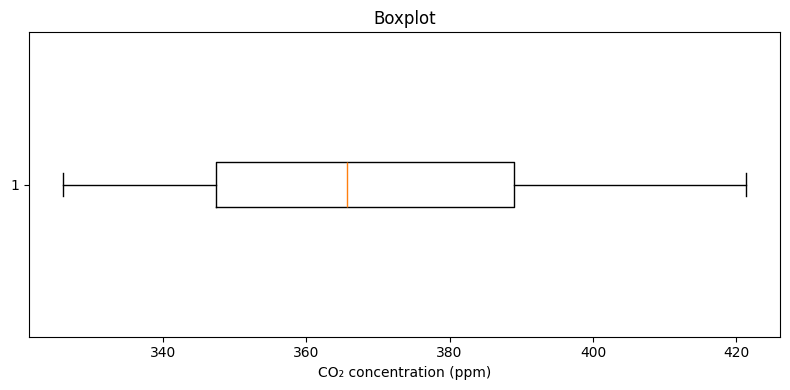

In [22]:
ds4_tests = run_diagnostics(
    ds4.dropna(),
    "co2",
    "Mauna Loa Daily Atmospheric CO₂",
    "CO₂ concentration (ppm)",
    rolling_window=365,
    acf_lags=1825,
    pacf_lags=730,
)

### Annual mean and seasonal-cycle checks

A yearly mean plot is used to make the long-term trend explicit. A month-of-year profile is also calculated to verify that a repeating annual seasonal cycle remains after the daily regularization.

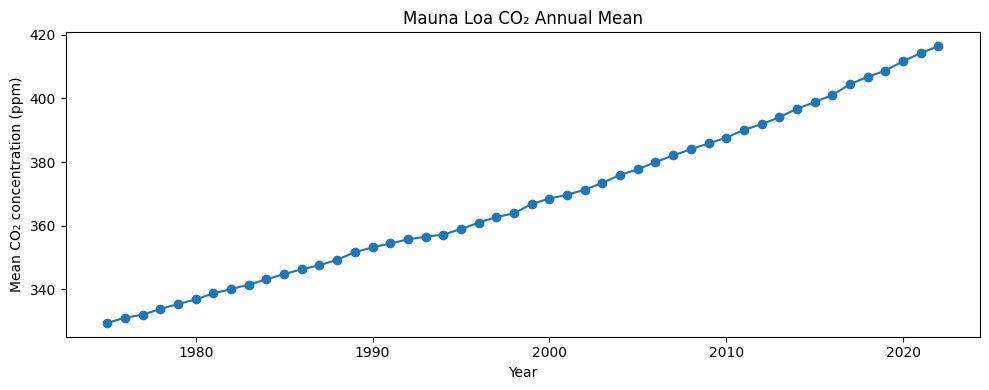

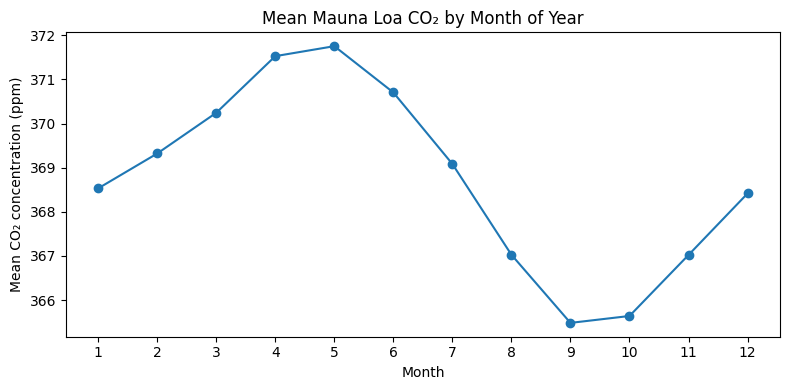

In [23]:
annual_mean = ds4["co2"].resample("YE").mean()

plt.figure(figsize=(10, 4))
plt.plot(annual_mean.index, annual_mean.values, marker="o")
plt.title("Mauna Loa CO₂ Annual Mean")
plt.xlabel("Year")
plt.ylabel("Mean CO₂ concentration (ppm)")
plt.tight_layout()
plt.show()

month_profile = ds4.groupby(ds4.index.month)["co2"].mean()

plt.figure(figsize=(8, 4))
plt.plot(month_profile.index, month_profile.values, marker="o")
plt.title("Mean Mauna Loa CO₂ by Month of Year")
plt.xlabel("Month")
plt.ylabel("Mean CO₂ concentration (ppm)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Preprocessing decision

The daily CO₂ series is kept in level form so that both the long-term trend and annual seasonality remain part of the forecasting problem. No differencing, detrending, deseasonalization, smoothing, or automatic outlier removal is applied. Missing calendar days are regularized by time interpolation after their gap lengths have been inspected. Scaling will be performed later inside each training fold only.

In [24]:
# Daily data:
# 30 ≈ 1 month, 180 ≈ 6 months,
# 365 = 1 year, 730 = 2 years
ds4_windows = [30, 180, 365, 730]

save_processed(ds4, "ds4.csv")
save_windows("ds4-windows.json", ds4_windows)

## Dataset 5: Noisy and irregular: Jena wind velocity

**Small explanation of the dataset:** The Jena Climate dataset contains weather measurements recorded at the Max Planck Institute for Biogeochemistry in Jena, Germany. Measurements were taken every 10 minutes. Only wind velocity (`wv (m/s)`) is used, and two complete calendar years are retained for the univariate forecasting task.

**Why it was chosen:** Wind velocity is substantially noisier and less regularly patterned than the other selected series. It therefore provides a useful test of how the recurrent architectures behave when short-term variation is high and predictable structure is weaker.

**Number of observations:** The 2009-2016 prepared dataset contains 420,551 10-minute rows. The 2014-2015 subset contains approximately 105,120 10-minute observations and becomes approximately 17,520 hourly observations after aggregation.

**Source:** https://keras.io/examples/timeseries/timeseries_weather_forecasting/

**Dataset file:** https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip

In [25]:
ds5base = pd.read_csv("raw-data/ds5.csv")
ds5base["Date Time"] = pd.to_datetime(
    ds5base["Date Time"],
    format="%d.%m.%Y %H:%M:%S",
)
ds5base = ds5base.sort_values("Date Time")
ds5base = ds5base[(ds5base["Date Time"] >= "2014-01-01") & (ds5base["Date Time"] < "2016-01-01")]
ds5 = ds5base[["Date Time", "wv (m/s)"]].rename(
    columns={"Date Time": "date", "wv (m/s)": "wind_velocity"}
).set_index("date")
ds5.head()

,wind_velocity
date,
2014-01-01 00:00:00,2.66
2014-01-01 00:10:00,2.25
2014-01-01 00:20:00,2.31
2014-01-01 00:30:00,2.58
2014-01-01 00:40:00,2.59


In [26]:
print(
    "Invalid -9999 wind-velocity values:",
    int((ds5["wind_velocity"] == -9999.0).sum())
)

# Convert source sentinel values to missing values.
ds5.loc[ds5["wind_velocity"] == -9999.0, "wind_velocity"] = np.nan

# Interpolate short gaps at the original 10-minute resolution.
ds5["wind_velocity"] = ds5["wind_velocity"].interpolate(
    method="time",
    limit_area="inside"
)

# Aggregate to hourly means.
ds5 = ds5.resample("h").mean()

# A few hourly bins may still be missing after aggregation; fill those
# small internal gaps on the regular hourly grid.
print(
    "Missing hourly wind values before final interpolation:",
    ds5["wind_velocity"].isna().sum()
)

ds5["wind_velocity"] = ds5["wind_velocity"].interpolate(
    method="time",
    limit_area="inside"
)

print(
    "Remaining missing hourly wind values:",
    ds5["wind_velocity"].isna().sum()
)

ds5.head()

Invalid -9999 wind-velocity values: 18
Missing hourly wind values before final interpolation: 15
Remaining missing hourly wind values: 0


,wind_velocity
date,
2014-01-01 00:00:00,2.673333
2014-01-01 01:00:00,3.046667
2014-01-01 02:00:00,2.630000
2014-01-01 03:00:00,1.825000
2014-01-01 04:00:00,0.908333


Shape: (17520, 1)
Start: 2014-01-01 00:00:00
End: 2015-12-31 23:00:00

Missing values:
wind_velocity    0
dtype: int64

Duplicate timestamps: 0

Summary:
count    17520.000000
mean         2.093852
std          1.486107
min          0.185000
25%          0.996667
50%          1.701667
75%          2.765000
max         23.201316
Name: wind_velocity, dtype: float64

Most common timestamp differences:
date
0 days 01:00:00    17519
Name: count, dtype: int64


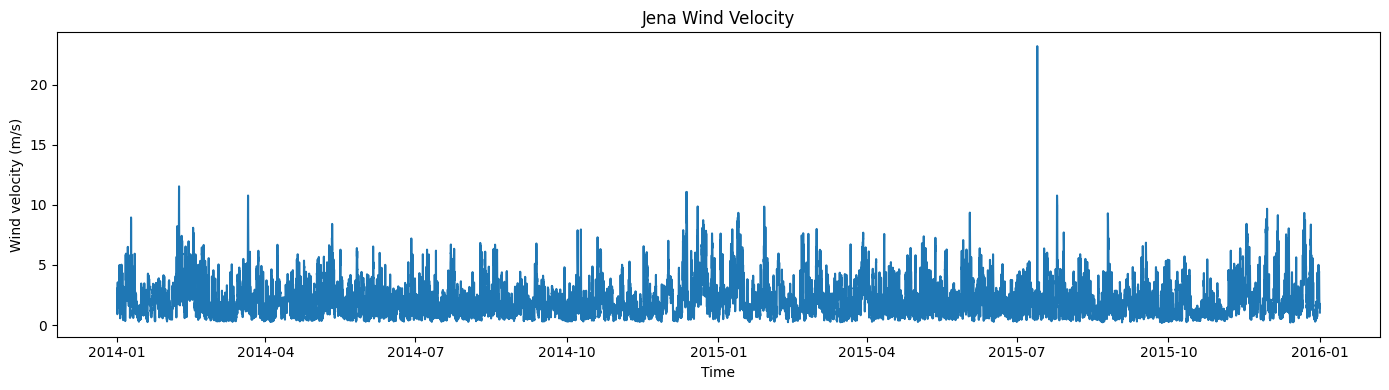

ADF statistic: -12.333737158476326
ADF p-value: 6.341400979406974e-23
KPSS statistic: 0.1959784443102625
KPSS p-value: 0.1


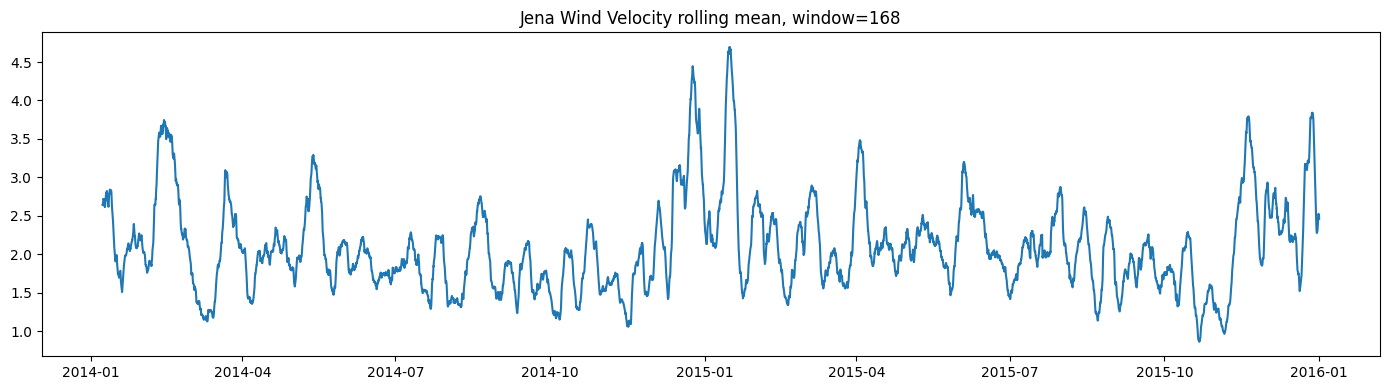

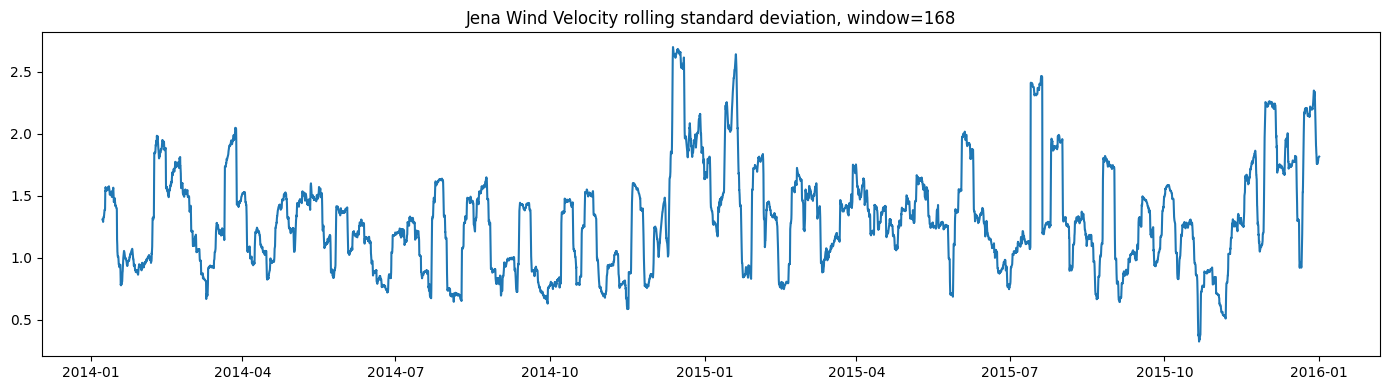

,mean,std,min,max
block,,,,
0,2.215739,1.489680,0.253333,11.541667
1,2.178796,1.436495,0.263333,10.778333
2,1.779146,1.113274,0.273333,7.206667
3,1.801793,1.220957,0.293333,7.956667
4,2.204072,1.716722,0.263333,11.080000
5,2.365225,1.636475,0.243333,9.856667
6,2.118684,1.406674,0.236667,7.688333
7,2.167199,1.545276,0.270000,23.201316
8,1.808094,1.275044,0.185000,9.296667


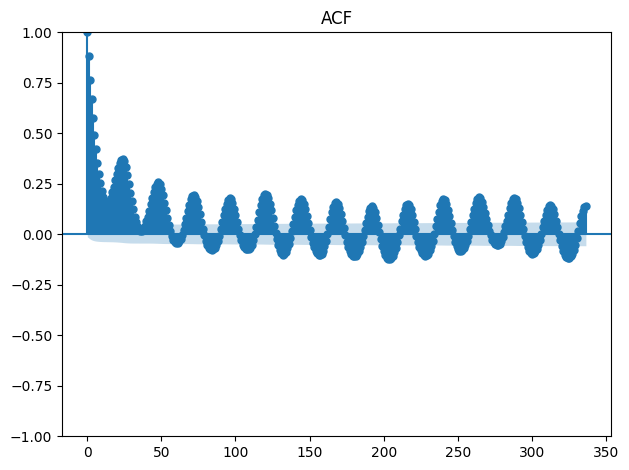

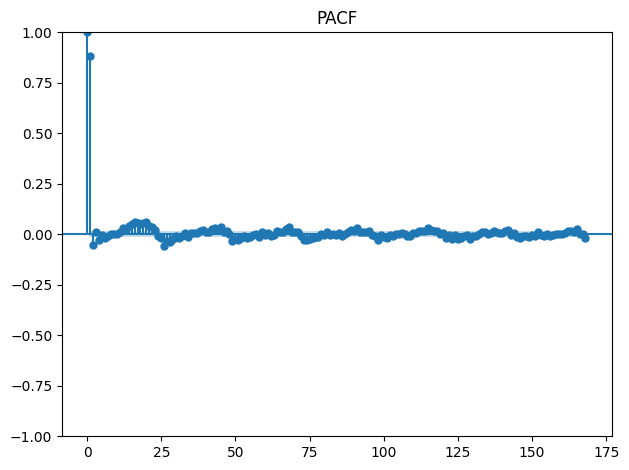

Number of |z| > 3 values: 269


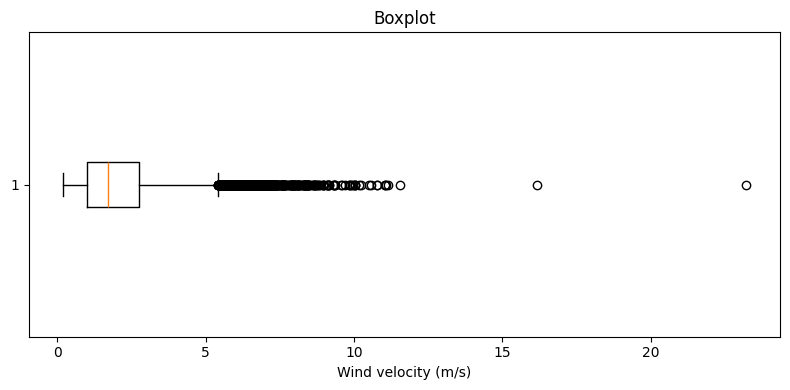

In [27]:
ds5_tests = run_diagnostics(
    ds5,
    "wind_velocity",
    "Jena Wind Velocity",
    "Wind velocity (m/s)",
    rolling_window=168,
    acf_lags=336,
    pacf_lags=168,
)

### Preprocessing decision

Two complete calendar years, 2014 and 2015, are retained so that the processed dataset contains roughly 17,500 hourly observations and remains close in size to the other forecasting problems. Invalid `-9999` wind-velocity sentinel values are converted to missing values and short internal gaps are interpolated in time. The 10-minute measurements are then aggregated to hourly means, after which any remaining small internal hourly gaps are also interpolated. Genuine high wind speeds are retained rather than automatically treated as outliers. Scaling will be performed later inside each training fold only.

In [28]:
# Hourly data:
# 6 = 6 hours, 24 = 1 day,
# 48 = 2 days, 168 = 1 week
ds5_windows = [6, 24, 48, 168]
save_processed(ds5, "ds5.csv")
save_windows("ds5-windows.json", ds5_windows)

# Final dataset summary

After the five sections have been run, the following table gives a compact check of the processed datasets. Final stationarity labels should be based on the diagnostics produced above rather than assumed in advance.

In [29]:
dataset_summary = pd.DataFrame([
    {
        "dataset": "Atmospheric pressure",
        "type": "Stationary baseline",
        "observations": len(ds1),
        "frequency": "10 min",
        "target": "Press_mm_hg",
    },
    {
        "dataset": "Bitcoin BTC/USD",
        "type": "Non-stationary non-seasonal",
        "observations": len(ds2),
        "frequency": "1 hour",
        "target": "bitcoin_close",
    },
    {
        "dataset": "Beijing temperature",
        "type": "Strongly seasonal",
        "observations": len(ds3),
        "frequency": "2 hours",
        "target": "temperature",
    },
    {
        "dataset": "Mauna Loa atmospheric CO2",
        "type": "Trend and seasonal",
        "observations": len(ds4),
        "frequency": "1 day",
        "target": "co2",
    },
    {
        "dataset": "Jena wind velocity",
        "type": "Noisy and irregular",
        "observations": len(ds5),
        "frequency": "1 hour",
        "target": "wind_velocity",
    },
])
dataset_summary

,dataset,type,observations,frequency,target
0,Atmospheric pressure,Stationary baseline,19735,10 min,Press_mm_hg
1,Bitcoin BTC/USD,Non-stationary non-seasonal,20000,1 hour,bitcoin_close
2,Beijing temperature,Strongly seasonal,21912,2 hours,temperature
3,Mauna Loa atmospheric CO2,Trend and seasonal,17394,1 day,co2
4,Jena wind velocity,Noisy and irregular,17520,1 hour,wind_velocity


## Seasonality diagnostics

The following diagnostics check plausible daily, weekly, and annual periods for each processed dataset.
They use only the first 80% of each series, matching the development/test split used in the forecasting experiments.
For each candidate period, STL seasonal strength and autocorrelation at that lag after removing the estimated trend are reported.
Progress messages identify each fit while the cell runs.
These are descriptive diagnostics, not formal significance tests; interpret strength and autocorrelation as evidence about recurring structure rather than proof of seasonality.
At least two complete cycles are required for each diagnostic.

In [30]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf

# Candidate periods are expressed in observations at each processed frequency.
# Annual periods use 365 days, including for the two-hour Beijing series.
seasonal_datasets = [
    ("Atmospheric pressure", ds1["Press_mm_hg"], [("daily", 144), ("weekly", 1008)]),
    ("Bitcoin BTC/USD", ds2["bitcoin_close"], [("daily", 24), ("weekly", 168)]),
    ("Beijing temperature", ds3["temperature"], [("daily", 12), ("annual", 4380)]),
    ("Mauna Loa CO2", ds4["co2"], [("annual", 365)]),
    ("Jena wind velocity", ds5["wind_velocity"], [("daily", 24), ("weekly", 168)]),
]

seasonality_rows = []
for dataset_name, series, candidate_periods in seasonal_datasets:
    development_size = int(len(series) * 0.8)
    development_series = series.iloc[:development_size].dropna().astype(float)

    for pattern_name, period in candidate_periods:
        if len(development_series) < 2 * period:
            seasonality_rows.append({
                "dataset": dataset_name,
                "candidate pattern": pattern_name,
                "period (observations)": period,
                "complete development cycles": len(development_series) / period,
                "detrended ACF at period": np.nan,
                "STL seasonal strength": np.nan,
                "status": "Skipped: fewer than two complete cycles",
            })
            continue

        print(f"Evaluating {dataset_name}: {pattern_name} (period={period})...")
        decomposition = STL(
            development_series,
            period=period,
            robust=False,
        ).fit()
        seasonal_component = np.asarray(decomposition.seasonal)
        remainder = np.asarray(decomposition.resid)
        strength_denominator = np.var(seasonal_component + remainder, ddof=1)
        if strength_denominator == 0:
            seasonal_strength = np.nan
        else:
            seasonal_strength = max(
                0.0,
                1.0 - np.var(remainder, ddof=1) / strength_denominator,
            )

        detrended_series = development_series.to_numpy() - np.asarray(decomposition.trend)
        detrended_acf = acf(detrended_series, nlags=period, fft=True)[period]
        seasonality_rows.append({
            "dataset": dataset_name,
            "candidate pattern": pattern_name,
            "period (observations)": period,
            "complete development cycles": len(development_series) / period,
            "detrended ACF at period": detrended_acf,
            "STL seasonal strength": seasonal_strength,
            "status": "Computed",
        })

seasonality_results = pd.DataFrame(seasonality_rows)
display(seasonality_results.round(3))

Evaluating Atmospheric pressure: daily (period=144)...
Evaluating Atmospheric pressure: weekly (period=1008)...
Evaluating Bitcoin BTC/USD: daily (period=24)...
Evaluating Bitcoin BTC/USD: weekly (period=168)...
Evaluating Beijing temperature: daily (period=12)...
Evaluating Beijing temperature: annual (period=4380)...
Evaluating Mauna Loa CO2: annual (period=365)...
Evaluating Jena wind velocity: daily (period=24)...
Evaluating Jena wind velocity: weekly (period=168)...


,dataset,candidate pattern,period (observations),complete development cycles,detrended ACF at period,STL seasonal strength,status
0,Atmospheric pressure,daily,144,109.639,-0.096,0.242,Computed
1,Atmospheric pressure,weekly,1008,15.663,0.045,0.423,Computed
2,Bitcoin BTC/USD,daily,24,666.667,-0.109,0.273,Computed
3,Bitcoin BTC/USD,weekly,168,95.238,-0.078,0.309,Computed
4,Beijing temperature,daily,12,1460.750,0.834,0.890,Computed
5,Beijing temperature,annual,4380,4.002,0.699,0.972,Computed
6,Mauna Loa CO2,annual,365,38.123,0.912,0.958,Computed
7,Jena wind velocity,daily,24,584.000,0.348,0.571,Computed
8,Jena wind velocity,weekly,168,83.429,0.202,0.473,Computed
